In [60]:

import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score,classification_report, average_precision_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define Features and target variable

In [15]:
# Define features and target variable
features = [
    # encoded station/service
    'StationCode_TE',
    'Service:Type_Intercity',
    'Service:Type_Intercity direct',
    'Service:Type_Sprinter',
    # temporal
    'Hour_sin',
    'Hour_cos',
    'DayOfWeek_sin',
    'DayOfWeek_cos',
    'Month_sin',
    'Month_cos',
    'IsWeekend',
    'RushHour',
    # operational context
    'StationTraffic',
    'Stop:Platform change',
    'arrival_scheduled',
    'departure_scheduled',
    # weather
    'Wind Direction',
    'Hourly Mean Wind Speed',
    'Wind Speed last 10 Minutes',
    'Max Wind Speed',
    'Temperature',
    'Dew Point temperature',
    'Sunshine Duration',
    'Global Radiation',
    'Precipitation Duration',
    'Precipitation Amount',
    'Air Pressure',
    'Horizontal Visibility',
    'Cloud Cover',
    'Humidity',
    'Fog',
    'Rainfall',
    'Snowfall',
    'Thunder',
    'Hail',
]

target = "is_cancelled"

# Define chunck reader

In [33]:
# Prepare for chunked reading
cols = features + [target]
chunk_size = 1_000_000
sample_size = 5_000_000
random_state = 42

dtype_map = {col: "float32" for col in features}
dtype_map[target] = "int8"


# Read CSV in chunks
def chunk_reader(file_path):
    for chunk in pd.read_csv(
        file_path,
        usecols=cols,
        dtype=dtype_map,
        chunksize=chunk_size
    ):
        chunk = chunk.reindex(columns=cols, fill_value=0) # Ensure all columns are present

        X_chunk = chunk[features]
        y_chunk = chunk[target]

        yield X_chunk, y_chunk # Yield the chunk for processing
        
# Count classes
not_cancelled_total = 0
cancelled_total = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):
    not_cancelled_total += (y_chunk == 0).sum()
    cancelled_total += (y_chunk == 1).sum()

total_rows = not_cancelled_total + cancelled_total

print(f"Train not cancelled: {not_cancelled_total:,}")
print(f"Train cancelled: {cancelled_total:,}")
print(f"Train total:     {total_rows:,}")

# Decide sample sizes
not_cancelled_sample_size = int(sample_size * not_cancelled_total / total_rows)
cancelled_sample_size = sample_size - not_cancelled_sample_size

print(f"Sampling not cancelled: {not_cancelled_sample_size:,}")
print(f"Sampling cancelled: {cancelled_sample_size:,}")

Train not cancelled: 43,903,090
Train cancelled: 4,479,366
Train total:     48,382,456
Sampling not cancelled: 4,537,087
Sampling cancelled: 462,913


# Distribution cancelled/not cancelled 

In [34]:
# Generate random numbers for sampling (default_rng is faster)
rng = np.random.default_rng(random_state)

X_not_cancelled_parts = []
y_not_cancelled_parts = []
X_cancelled_parts = []
y_cancelled_parts = []

not_cancelled_seen = 0
cancelled_seen = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):

    # Create masks for cancelled and not cancelled
    not_cancelled_mask = y_chunk == 0
    cancelled_mask = y_chunk == 1
    
    # Split the chunk into cancelled and not cancelled
    X_not_cancelled = X_chunk.loc[not_cancelled_mask]
    y_not_cancelled = y_chunk.loc[not_cancelled_mask]

    X_cancelled = X_chunk.loc[cancelled_mask]
    y_cancelled = y_chunk.loc[cancelled_mask]

    # sample fraction based on remaining needed / remaining available
    neg_remaining_needed = not_cancelled_sample_size - sum(len(p) for p in y_not_cancelled_parts)
    pos_remaining_needed = cancelled_sample_size - sum(len(p) for p in y_cancelled_parts)

    neg_remaining_total = not_cancelled_total - not_cancelled_seen
    pos_remaining_total = cancelled_total - cancelled_seen

    # Sample not cancelled
    if neg_remaining_needed > 0 and len(X_not_cancelled) > 0:
        p_neg = min(1.0, neg_remaining_needed / max(neg_remaining_total, 1))
        keep_neg = rng.random(len(X_not_cancelled)) < p_neg

        X_not_cancelled_parts.append(X_not_cancelled.loc[keep_neg])
        y_not_cancelled_parts.append(y_not_cancelled.loc[keep_neg])
        
    # Sample cancelled
    if pos_remaining_needed > 0 and len(X_cancelled) > 0:
        p_pos = min(1.0, pos_remaining_needed / max(pos_remaining_total, 1))
        keep_pos = rng.random(len(X_cancelled)) < p_pos

        X_cancelled_parts.append(X_cancelled.loc[keep_pos])
        y_cancelled_parts.append(y_cancelled.loc[keep_pos])

    not_cancelled_seen += len(X_not_cancelled)
    cancelled_seen += len(X_cancelled)

# Combine sampled parts
X_train_sample = pd.concat(X_not_cancelled_parts + X_cancelled_parts, axis=0)
y_train_sample = pd.concat(y_not_cancelled_parts + y_cancelled_parts, axis=0)

# Shuffle final sample
shuffle_idx = rng.permutation(len(X_train_sample))
X_train_sample = X_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.float32, copy=False)
y_train_sample = y_train_sample.iloc[shuffle_idx].to_numpy(copy=False)

# Finding the best Parameters

In [ ]:
# runtime 70m69s
# # Custom F2 scorer
# f2_scorer = make_scorer(fbeta_score, beta=2)

# # Calculate imbalance ratio for XGBoost
# neg_count = np.sum(y_train_sample == 0)
# pos_count = np.sum(y_train_sample == 1)

# scale_pos_weight_base = neg_count / pos_count

# print("Negative count:", neg_count)
# print("Positive count:", pos_count)
# print("Base scale_pos_weight:", round(scale_pos_weight_base, 2))


# # XGBoost parameter grid for imbalanced classification
# param_dist = {
#     "n_estimators": [100, 200, 300, 500, 800],
#     "max_depth": [4, 5, 6, 8, 10],
#     "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
#     "subsample": [0.6, 0.8, 1.0],
#     "colsample_bytree": [0.6, 0.8, 1.0],
#     "min_child_weight": [10, 20, 50, 75, 100],
#     "gamma": [0, 0.5, 1, 2, 5],
#     "reg_alpha": [0, 0.1, 0.5, 1, 2],
#     "reg_lambda": [1, 2, 5, 10, 20],

#     # XGBoost's class imbalance parameter
#     "scale_pos_weight": [
#         scale_pos_weight_base * 1,
#         scale_pos_weight_base * 3,
#         scale_pos_weight_base * 5,
#         scale_pos_weight_base * 7,
#     ],
# }

# # Use smaller subset for tuning
# X_tune, X_val_tune, y_tune, y_val_tune = train_test_split(
#     X_train_sample,
#     y_train_sample,
#     train_size=0.3,
#     stratify=y_train_sample,
#     random_state=42
# )

# # Base XGBoost model
# xgb = XGBClassifier(
#     objective="binary:logistic",
#     eval_metric="aucpr",
#     tree_method="hist",
#     random_state=42,
#     n_jobs=-1
# )

# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# # Random search
# xgb_tuned = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=50,
#     scoring=f2_scorer,
#     cv=cv,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

# xgb_tuned.fit(X_tune, y_tune)

# print("Best CV F2 score:", round(xgb_tuned.best_score_, 4))
# print("Best parameters:")
# print(xgb_tuned.best_params_)

# # Results from tuning run on 30% of training data (5M samples):
# # Negative count: 4536916
# # Positive count: 462908
# # Base scale_pos_weight: 9.8
# # Fitting 5 folds for each of 50 candidates, totalling 250 fits
# # Best CV F2 score: 0.4628
# # Best parameters:
# # {'subsample': 0.6, 'scale_pos_weight': np.float64(9.800902123100055), 
# # 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 50, 
# # 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 1.0}

Negative count: 4536916
Positive count: 462908
Base scale_pos_weight: 9.8
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV F2 score: 0.4628
Best parameters:
{'subsample': 0.6, 'scale_pos_weight': np.float64(9.800902123100055), 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 50, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 2, 'colsample_bytree': 1.0}


# Define Evaluation Method

In [36]:
# Evaluate CSV split in chunks with custom threshold
def evaluate_split_xgb(name, file_path, model, threshold):
    y_true_parts = []
    y_pred_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_pred_parts.append(y_pred)
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_pred_all = np.concatenate(y_pred_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    f2 = fbeta_score(y_true_all, y_pred_all, beta=2)
    pr_auc = average_precision_score(y_true_all, y_prob_all)

    print(f"\n{name}")
    print("Threshold:", round(threshold, 2))
    print("F2 Score:", round(f2, 4))
    print(classification_report(y_true_all, y_pred_all, digits=3, zero_division=0))
    print("PR-AUC:", round(pr_auc, 4))

    return {
        "threshold": threshold,
        "f2": f2,
        "pr_auc": pr_auc
    }


# Find best threshold using validation data
def find_best_threshold_xgb(file_path, model):
    y_true_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    best_threshold = 0.5
    best_f2 = -1

    for threshold in np.arange(0.01, 0.99, 0.01):
        y_pred_all = (y_prob_all >= threshold).astype(int)
        f2 = fbeta_score(y_true_all, y_pred_all, beta=2)

        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold

    print("Best validation threshold:", round(best_threshold, 2))
    print("Best validation F2:", round(best_f2, 4))

    return best_threshold

# XGBoost: Class weighting (BEST MODEL)

In [37]:
# Train final model with best parameters on full sample
best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 5.0,
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_class = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_class.fit(X_train_sample, y_train_sample)

print(f"XGBoost trained on {len(y_train_sample):,} samples")

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_class)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_class,
    threshold=best_threshold
)

XGBoost trained on 4,999,824 samples
Best validation threshold: 0.22
Best validation F2: 0.3825

Train
Threshold: 0.22
F2 Score: 0.4223
              precision    recall  f1-score   support

           0      0.976     0.413     0.580  43903090
           1      0.135     0.900     0.235   4479366

    accuracy                          0.458  48382456
   macro avg      0.556     0.656     0.408  48382456
weighted avg      0.898     0.458     0.548  48382456

PR-AUC: 0.3747

Validation
Threshold: 0.22
F2 Score: 0.3825
              precision    recall  f1-score   support

           0      0.943     0.401     0.563   9333880
           1      0.126     0.779     0.217   1033789

    accuracy                          0.439  10367669
   macro avg      0.534     0.590     0.390  10367669
weighted avg      0.861     0.439     0.529  10367669

PR-AUC: 0.1678

Test
Threshold: 0.22
F2 Score: 0.4334
              precision    recall  f1-score   support

           0      0.934     0.363     0.5

# XGBoost: RandomUnderSampler

In [39]:

# Train model with best parameters on full sample with undersampling
rus = RandomUnderSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train_sample,
    y_train_sample
)

print("Before:", Counter(y_train_sample))
print("After:", Counter(y_train_under))

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_rus = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_rus.fit(X_train_under, y_train_under)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_rus)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_rus,
    threshold=best_threshold
)

Before: Counter({np.int8(0): 4536916, np.int8(1): 462908})
After: Counter({np.int8(0): 1851632, np.int8(1): 462908})
Best validation threshold: 0.12
Best validation F2: 0.381

Train
Threshold: 0.12
F2 Score: 0.4112
              precision    recall  f1-score   support

           0      0.976     0.374     0.541  43903090
           1      0.129     0.908     0.226   4479366

    accuracy                          0.424  48382456
   macro avg      0.552     0.641     0.383  48382456
weighted avg      0.897     0.424     0.512  48382456

PR-AUC: 0.3687

Validation
Threshold: 0.12
F2 Score: 0.381
              precision    recall  f1-score   support

           0      0.944     0.357     0.518   9333880
           1      0.122     0.809     0.212   1033789

    accuracy                          0.402  10367669
   macro avg      0.533     0.583     0.365  10367669
weighted avg      0.862     0.402     0.488  10367669

PR-AUC: 0.1664

Test
Threshold: 0.12
F2 Score: 0.4299
              prec

# XGBoost: RandomOverSampler

In [40]:
# Train model with best parameters on full sample with oversampling
ros = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_over, y_train_over = ros.fit_resample(
    X_train_sample,
    y_train_sample
)

print("Before:", Counter(y_train_sample))
print("After:", Counter(y_train_over))

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_ros = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_ros.fit(X_train_over, y_train_over)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_ros)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_ros,
    threshold=best_threshold
)

Before: Counter({np.int8(0): 4536916, np.int8(1): 462908})
After: Counter({np.int8(0): 4536916, np.int8(1): 1134229})
Best validation threshold: 0.12
Best validation F2: 0.3816

Train
Threshold: 0.12
F2 Score: 0.4147
              precision    recall  f1-score   support

           0      0.976     0.385     0.552  43903090
           1      0.131     0.907     0.229   4479366

    accuracy                          0.433  48382456
   macro avg      0.553     0.646     0.390  48382456
weighted avg      0.898     0.433     0.522  48382456

PR-AUC: 0.378

Validation
Threshold: 0.12
F2 Score: 0.3816
              precision    recall  f1-score   support

           0      0.944     0.363     0.525   9333880
           1      0.123     0.805     0.213   1033789

    accuracy                          0.407  10367669
   macro avg      0.533     0.584     0.369  10367669
weighted avg      0.862     0.407     0.494  10367669

PR-AUC: 0.166

Test
Threshold: 0.12
F2 Score: 0.4299
              pre

# XGBoost: Sample weighting

In [41]:
# Sample weighting
sample_weight = np.where(y_train_sample == 1, 5.0, 1.0)

best_params = {
    "subsample": 0.6,
    "scale_pos_weight": 1.0, 
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 200,
    "min_child_weight": 50,
    "max_depth": 10,
    "learning_rate": 0.05,
    "gamma": 2,
    "colsample_bytree": 1.0
}

xgb_weighted = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_weighted.fit(
    X_train_sample,
    y_train_sample,
    sample_weight=sample_weight
)

best_threshold = find_best_threshold_xgb("val_data.csv", xgb_weighted)

train_results = evaluate_split_xgb(
    name="Train",
    file_path="train_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

val_results = evaluate_split_xgb(
    name="Validation",
    file_path="val_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

test_results = evaluate_split_xgb(
    name="Test",
    file_path="test_data.csv",
    model=xgb_weighted,
    threshold=best_threshold
)

Best validation threshold: 0.21
Best validation F2: 0.3816

Train
Threshold: 0.21
F2 Score: 0.4162
              precision    recall  f1-score   support

           0      0.977     0.382     0.549  43903090
           1      0.131     0.914     0.229   4479366

    accuracy                          0.431  48382456
   macro avg      0.554     0.648     0.389  48382456
weighted avg      0.899     0.431     0.519  48382456

PR-AUC: 0.3775

Validation
Threshold: 0.21
F2 Score: 0.3816
              precision    recall  f1-score   support

           0      0.944     0.372     0.534   9333880
           1      0.124     0.799     0.214   1033789

    accuracy                          0.415  10367669
   macro avg      0.534     0.586     0.374  10367669
weighted avg      0.862     0.415     0.502  10367669

PR-AUC: 0.168

Test
Threshold: 0.21
F2 Score: 0.43
              precision    recall  f1-score   support

           0      0.933     0.336     0.494   9105889
           1      0.147    

# Feature Importance

In [42]:
# Feature importance analysis with best model - XGBoost: Class weighting (xgb_class)
importance_gain = xgb_class.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature_index": importance_gain.keys(),
    "gain": importance_gain.values()
})

importance_df["feature"] = importance_df["feature_index"].apply(
    lambda x: features[int(x[1:])]
)

importance_df = importance_df[["feature", "gain"]].sort_values(
    "gain",
    ascending=False
)

print(importance_df.head(20))

                          feature         gain
3           Service:Type_Sprinter  2060.983154
12           Stop:Platform change   621.060303
2   Service:Type_Intercity direct   367.096588
13              arrival_scheduled   318.579620
14            departure_scheduled   308.187927
8                       Month_sin   170.165176
9                       Month_cos   162.750092
6                   DayOfWeek_sin   134.977493
16         Hourly Mean Wind Speed   133.181168
25                   Air Pressure   131.886185
7                   DayOfWeek_cos   130.055298
18                 Max Wind Speed   127.103813
0                  StationCode_TE   120.588562
20          Dew Point temperature   118.224915
31                       Snowfall   117.552948
5                        Hour_cos   116.679749
19                    Temperature   114.030846
24           Precipitation Amount   113.355415
15                 Wind Direction   112.149872
23         Precipitation Duration   103.147430


In [43]:
# Create validation set for permutation importance

X_val_perm, y_val_perm = next(chunk_reader("val_data.csv"))

X_val_perm = X_val_perm.to_numpy(dtype=np.float32, copy=False)
y_val_perm = y_val_perm.to_numpy(copy=False)

print("Permutation validation sample shape:", X_val_perm.shape)
print("Permutation validation target shape:", y_val_perm.shape)

best_threshold = 0.25

def f2_threshold_scorer(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    return fbeta_score(y, y_pred, beta=2)

perm = permutation_importance(
    xgb_class,
    X_val_perm,
    y_val_perm,
    scoring=f2_threshold_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 permutation importances:")
print(perm_df.head(20))

print("\nLowest 10 permutation importances:")
print(perm_df.tail(10))

Permutation validation sample shape: (1000000, 35)
Permutation validation target shape: (1000000,)

Top 20 permutation importances:
                          feature  importance_mean  importance_std
3           Service:Type_Sprinter         0.065459        0.000527
0                  StationCode_TE         0.065312        0.000704
13           Stop:Platform change         0.009150        0.000162
14              arrival_scheduled         0.006322        0.000172
15            departure_scheduled         0.006074        0.000089
12                 StationTraffic         0.004886        0.000294
16                 Wind Direction         0.004688        0.000226
5                        Hour_cos         0.003635        0.000452
20                    Temperature         0.002935        0.000243
27          Horizontal Visibility         0.002881        0.000201
26                   Air Pressure         0.002232        0.000227
7                   DayOfWeek_cos         0.001598        0.0001

# Error Analysis

In [53]:
# Get predictions for test set in a DataFrame
def get_predictions_dataframe(file_path, model, threshold):
    parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        chunk_results = X_chunk.copy()
        chunk_results["y_true"] = y_chunk.to_numpy(copy=False)
        chunk_results["y_prob"] = y_prob
        chunk_results["y_pred"] = y_pred

        parts.append(chunk_results)

    return pd.concat(parts, axis=0, ignore_index=True)


test_pred_df = get_predictions_dataframe(
    file_path="test_data.csv",
    model=xgb_class,
    threshold=0.25
)

test_pred_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10367670 entries, 0 to 10367669
Data columns (total 38 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   StationCode_TE                 float32
 1   Service:Type_Intercity         float32
 2   Service:Type_Intercity direct  float32
 3   Service:Type_Sprinter          float32
 4   Hour_sin                       float32
 5   Hour_cos                       float32
 6   DayOfWeek_sin                  float32
 7   DayOfWeek_cos                  float32
 8   Month_sin                      float32
 9   Month_cos                      float32
 10  IsWeekend                      float32
 11  RushHour                       float32
 12  StationTraffic                 float32
 13  Stop:Platform change           float32
 14  arrival_scheduled              float32
 15  departure_scheduled            float32
 16  Wind Direction                 float32
 17  Hourly Mean Wind Speed         float32
 18  Wind Speed 

# Confusion Matrix

[[4311557 4794332]
 [ 342344  919437]]


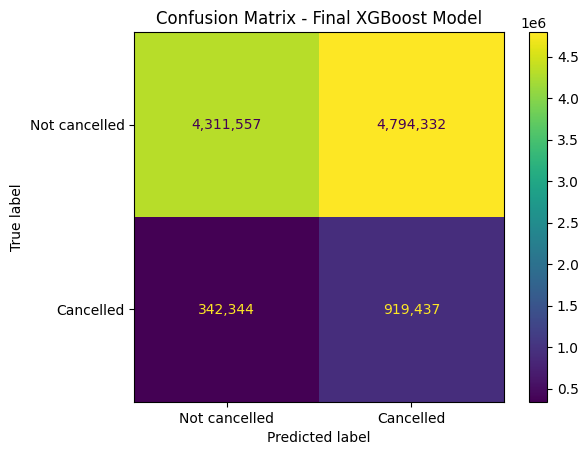

In [ ]:
# Confusion matrix for test set
cm = confusion_matrix(
    test_pred_df["y_true"],
    test_pred_df["y_pred"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not cancelled", "Cancelled"]
)

disp.plot(values_format=",d")
plt.title("Confusion Matrix - Final XGBoost Model")
plt.show()

In [56]:
test_pred_df["error_type"] = np.select(
    [
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 1),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 1),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unknown"
)

print(test_pred_df["error_type"].value_counts())

error_type
False Positive    4794332
True Negative     4311557
True Positive      919437
False Negative     342344
Name: count, dtype: int64


# Subgroup bias analysis

In [ ]:
# Subgroups are:
# StationCode_TE
# Service type
# Hour / RushHour
# IsWeekend
# StationTraffic

def subgroup_metrics(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        rows.append({
            "group": group_value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("f2", ascending=True)


print(subgroup_metrics(test_pred_df, "Service:Type_Intercity"))
print(subgroup_metrics(test_pred_df, "Service:Type_Sprinter"))
print(subgroup_metrics(test_pred_df, "IsWeekend"))
print(subgroup_metrics(test_pred_df, "RushHour"))

# For one-hot service type, create one readable service column first:
def get_service_type(row):
    if row["Service:Type_Intercity"] == 1:
        return "Intercity"
    elif row["Service:Type_Intercity direct"] == 1:
        return "Intercity direct"
    elif row["Service:Type_Sprinter"] == 1:
        return "Sprinter"
    else:
        return "Other"

test_pred_df["service_type"] = test_pred_df.apply(get_service_type, axis=1)

service_bias = subgroup_metrics(test_pred_df, "service_type")
print(service_bias)

   group        n  actual_cancel_rate  predicted_cancel_rate  \
0    0.0  7038088            0.094014               0.386299   
1    1.0  3329582            0.180233               0.899502   

   precision_cancelled  recall_cancelled        f2  
0             0.128828          0.529349  0.326398  
1             0.190045          0.948469  0.527469  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  6846386            0.089536               0.376430   
0    0.0  3521284            0.184247               0.890751   

   precision_cancelled  recall_cancelled        f2  
1             0.120513          0.506664  0.308782  
0             0.194114          0.938453  0.531126  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  2476407            0.088803               0.450695   
0    0.0  7891263            0.132028               0.582627   

   precision_cancelled  recall_cancelled        f2  
1             0.132969          0.674844  0.371806

# Rare Weather Conditions analysis

In [58]:
weather_flags = ["Fog", "Rainfall", "Snowfall", "Thunder", "Hail"]

weather_results = []

for weather_col in weather_flags:
    for value, group_df in test_pred_df.groupby(weather_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        weather_results.append({
            "weather_feature": weather_col,
            "condition_present": value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

weather_results_df = pd.DataFrame(weather_results).sort_values(
    ["weather_feature", "condition_present"]
)

print(weather_results_df)

  weather_feature  condition_present         n  actual_cancel_rate  \
0             Fog                0.0  10121445            0.122847   
1             Fog                1.0    246225            0.074680   
8            Hail                0.0  10352688            0.121804   
9            Hail                1.0     14982            0.052196   
2        Rainfall                0.0   8570441            0.120835   
3        Rainfall                1.0   1797229            0.125847   
4        Snowfall                0.0  10360674            0.121727   
5        Snowfall                1.0      6996            0.087193   
6         Thunder                0.0  10309093            0.121899   
7         Thunder                1.0     58577            0.087304   

   predicted_cancel_rate  precision_cancelled  recall_cancelled        f2  
0               0.553380             0.161898          0.729287  0.428759  
1               0.457955             0.112159          0.687786  0.339404  
8